In [ ]:
!pip install tensorflow
!pip install tensorflow_probability
!pip install git+https://github.com/henrysky/astroNN.git

  Cloning https://github.com/henrysky/astroNN.git to /tmp/pip-req-build-abxxy020
  Running command git clone --filter=blob:none --quiet https://github.com/henrysky/astroNN.git /tmp/pip-req-build-abxxy020
  Resolved https://github.com/henrysky/astroNN.git to commit 41bc2bf5f537e1dd6aa2f9b27229267048b38db9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.7 MB/s eta 0:00:00
  Created wheel for astroNN: filename=astroNN-1.2.dev0-py3-none-any.whl size=116163 sha256=3c5beff75cd6d3d613505e9c92a93562c990d6289ed9b85d0bfcae8d2c958a0a
  Stored in directory: /tmp/pip-ephem-wheel-cache-8fqdu6ki/wheels/22/d1/2b/2a4d4d76da90d8da884392aae60ad54592660343cb5b8942c7
Successfully built astroNN
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling kera

Num GPUs Available:  1
Using GPU for training!
/root/.astroNN/datasets/Galaxy10.h5 was found!


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Epoch 1/5
218/218 - 20s - 91ms/step - accuracy: 0.4123 - loss: 1.4526 - val_accuracy: 0.5138 - val_loss: 1.1782
Epoch 2/5
218/218 - 7s - 33ms/step - accuracy: 0.5696 - loss: 1.1050 - val_accuracy: 0.6254 - val_loss: 0.9993
Epoch 3/5
218/218 - 5s - 21ms/step - accuracy: 0.6515 - loss: 0.9426 - val_accuracy: 0.6936 - val_loss: 0.8485
Epoch 4/5
218/218 - 4s - 20ms/step - accuracy: 0.7010 - loss: 0.8169 - val_accuracy: 0.7424 - val_loss: 0.7216
Epoch 5/5
218/218 - 4s - 20ms/step - accuracy: 0.7231 - loss: 0.7471 - val_accuracy: 0.7430 - val_loss: 0.7231


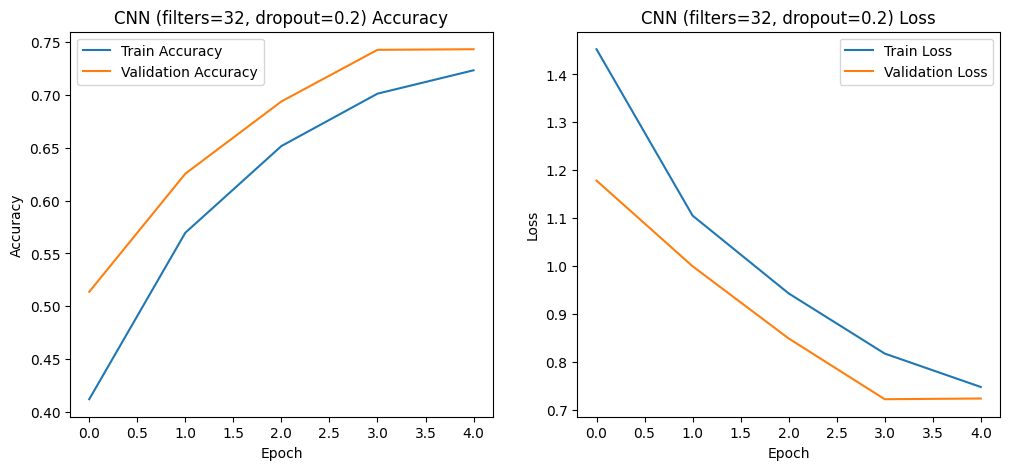

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


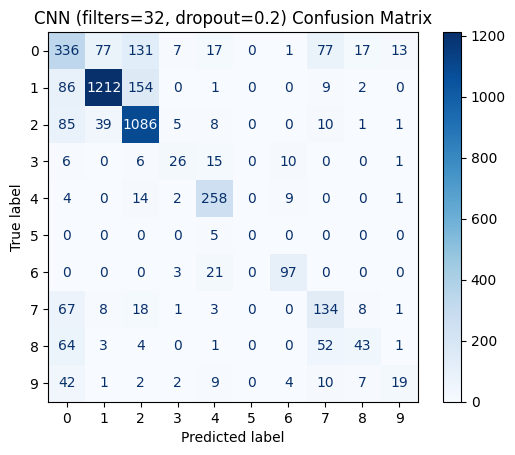

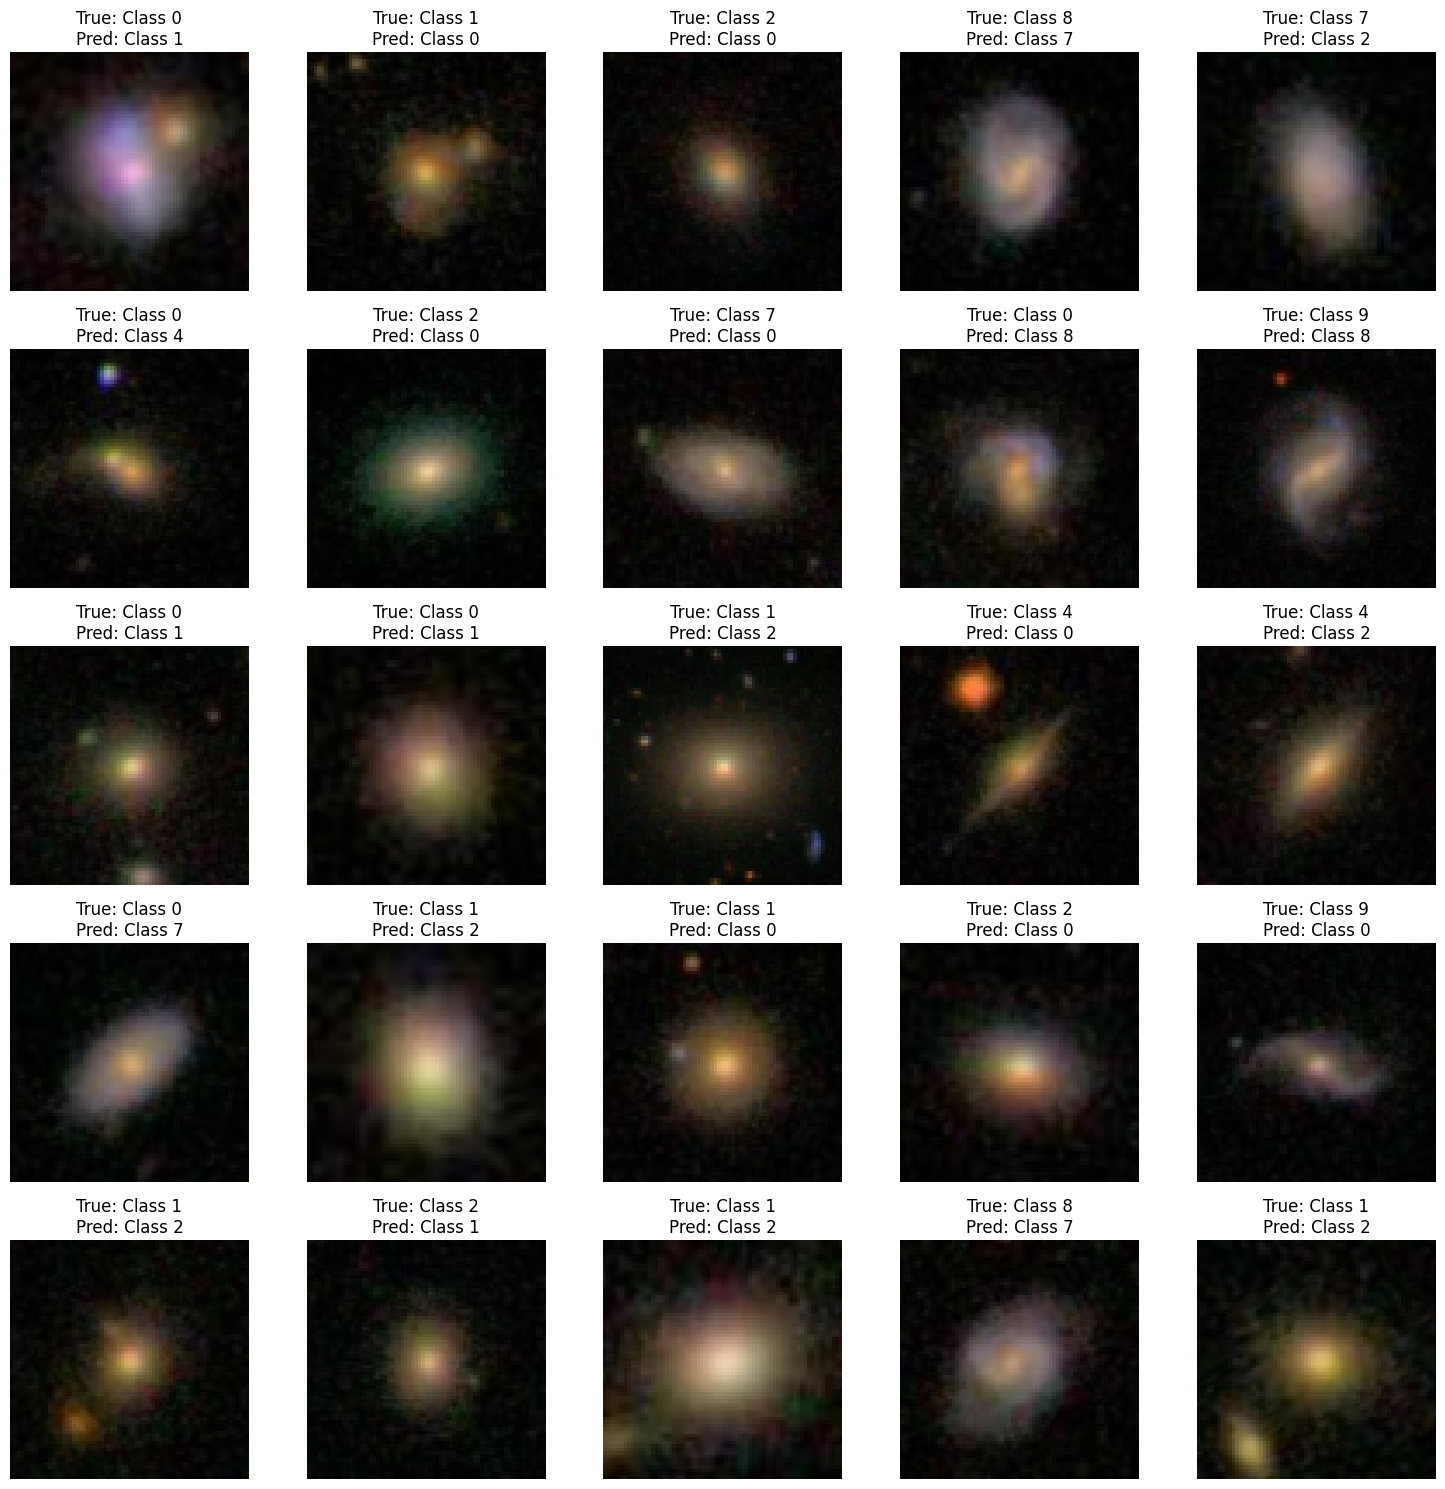

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
218/218 - 32s - 146ms/step - accuracy: 0.3820 - loss: 1.5183 - val_accuracy: 0.5184 - val_loss: 1.2279
Epoch 2/5
218/218 - 21s - 95ms/step - accuracy: 0.5076 - loss: 1.2502 - val_accuracy: 0.6027 - val_loss: 1.0709
Epoch 3/5
218/218 - 9s - 43ms/step - accuracy: 0.5702 - loss: 1.1285 - val_accuracy: 0.6213 - val_loss: 1.0261
Epoch 4/5
218/218 - 10s - 46ms/step - accuracy: 0.6037 - loss: 1.0506 - val_accuracy: 0.6589 - val_loss: 0.9371
Epoch 5/5
218/218 - 10s - 46ms/step - accuracy: 0.6395 - loss: 0.9586 - val_accuracy: 0.6928 - val_loss: 0.8410


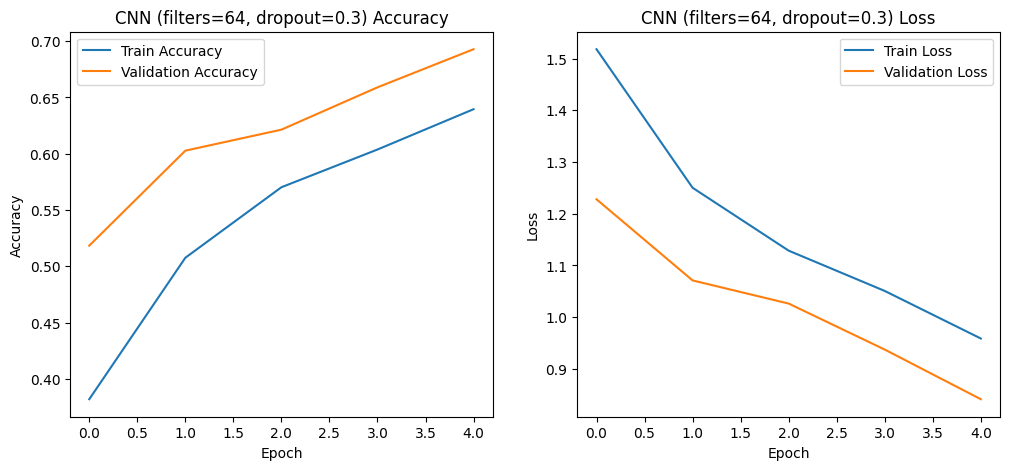

137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


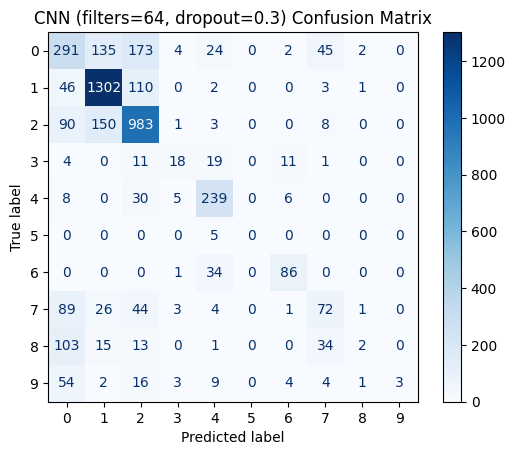

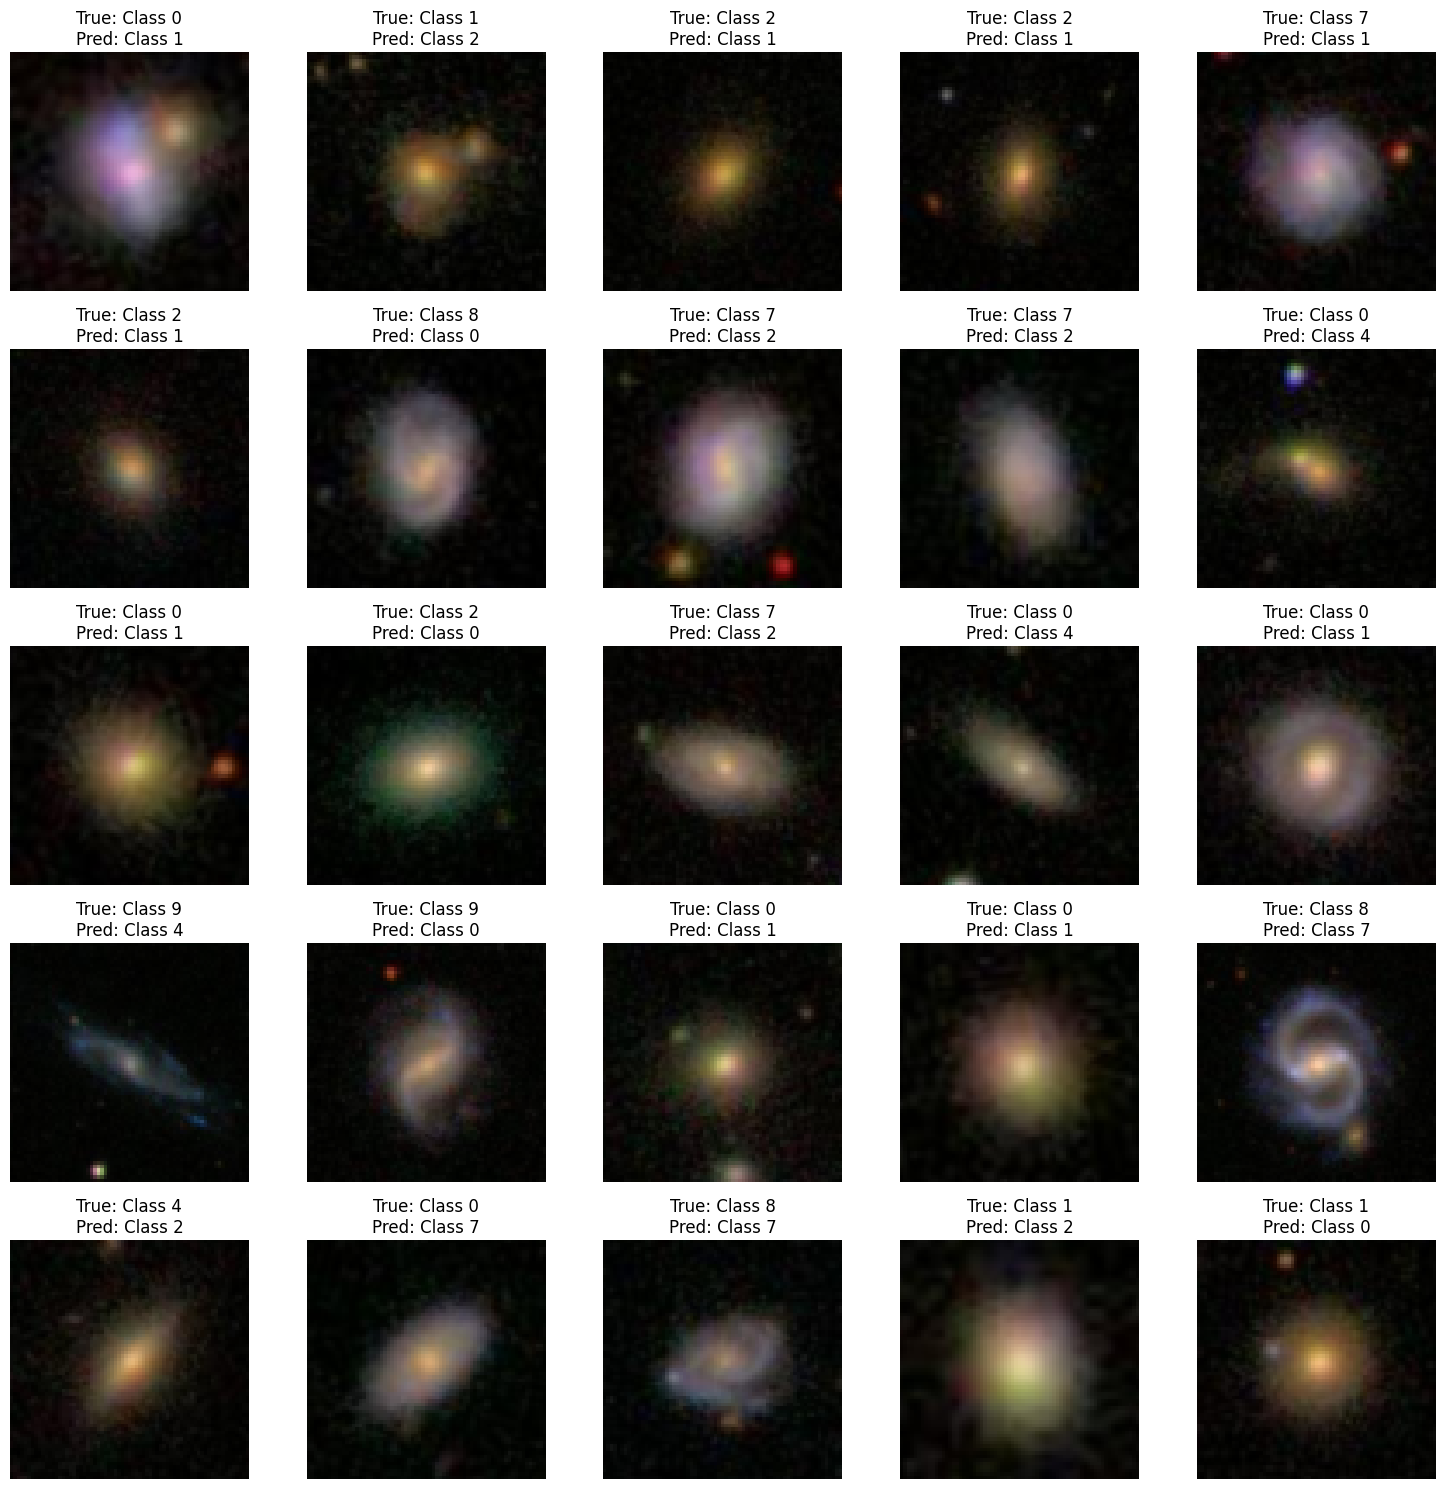

CNN (filters=32, dropout=0.2): Test Accuracy = 0.7370
CNN (filters=64, dropout=0.3): Test Accuracy = 0.6876


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from astroNN.datasets import load_galaxy10sdss
from sklearn.model_selection import train_test_split
import itertools

#  GPU availability
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
if len(tf.config.experimental.list_physical_devices('GPU')) > 0:
    print("Using GPU for training!")
else:
    print("GPU not detected. Using CPU for training.")

# Load Galaxy10 dataset
images, labels = load_galaxy10sdss()
labels = tf.keras.utils.to_categorical(labels, 10)
images = images.astype('float32') / 255.0

#
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)


def plot_metrics(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

#  create CNN models
def create_cnn(filters, dropout_rate):
    model = models.Sequential([
        layers.Conv2D(filters, (3, 3), activation='relu', input_shape=(69, 69, 3)),
        layers.Conv2D(filters, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate),
        layers.Conv2D(filters * 2, (3, 3), activation='relu'),
        layers.Conv2D(filters * 2, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

#  incorrectly classified images
def display_incorrect_classifications(images, true_labels, predicted_labels, class_names):
    incorrect_indices = np.where(true_labels != predicted_labels)[0]
    plt.figure(figsize=(15, 15))
    for i, idx in enumerate(incorrect_indices[:25]):  # Display incorrect examples
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[idx])
        plt.title(f"True: {class_names[true_labels[idx]]}\nPred: {class_names[predicted_labels[idx]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Train and evaluate models
results = []
for filters, dropout_rate in [(32, 0.2), (64, 0.3)]:
    model_name = f'CNN (filters={filters}, dropout={dropout_rate})'
    cnn_model = create_cnn(filters, dropout_rate)
    with tf.device('/GPU:0' if tf.test.is_gpu_available() else '/CPU:0'):
        history = cnn_model.fit(train_images, train_labels, validation_data=(val_images, val_labels),
                                epochs=5, batch_size=64, verbose=2)
    test_loss, test_acc = cnn_model.evaluate(test_images, test_labels, verbose=0)
    results.append((model_name, test_acc))

    # Plot metrics
    plot_metrics(history, model_name)

    # Confusion matrix
    predictions = np.argmax(cnn_model.predict(test_images), axis=1)
    true_labels = np.argmax(test_labels, axis=1)
    cm = confusion_matrix(true_labels, predictions)
    ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()


    class_names = [f"Class {i}" for i in range(10)]
    display_incorrect_classifications(test_images, true_labels, predictions, class_names)

# Print and compare results
results.sort(key=lambda x: -x[1])
for result in results:
    print(f'{result[0]}: Test Accuracy = {result[1]:.4f}')


/root/.astroNN/datasets/Galaxy10.h5 was found!
Training model with Patch Size: 4, Embed Dim: 64, Num Heads: 2, Num Layers: 2
Epoch 1/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.3393 - loss: 2.8174 - val_accuracy: 0.4712 - val_loss: 1.4492
Epoch 2/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5394 - loss: 1.3015 - val_accuracy: 0.6175 - val_loss: 1.0311
Epoch 3/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6184 - loss: 1.0488 - val_accuracy: 0.6349 - val_loss: 1.0017
Epoch 4/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6579 - loss: 0.9260 - val_accuracy: 0.6410 - val_loss: 0.9751
Epoch 5/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6767 - loss: 0.8576 - val_accuracy: 0.6634 - val_loss: 0.9420
Model with Patch Size: 4, Embed Dim: 64, Num Heads: 2, Num Layers: 2 achieved Test Accuracy: 0.6563
Training model with Patch Size: 4, Embed Dim: 64, Num Heads: 2, Num Layers: 3
Epoch 1/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step

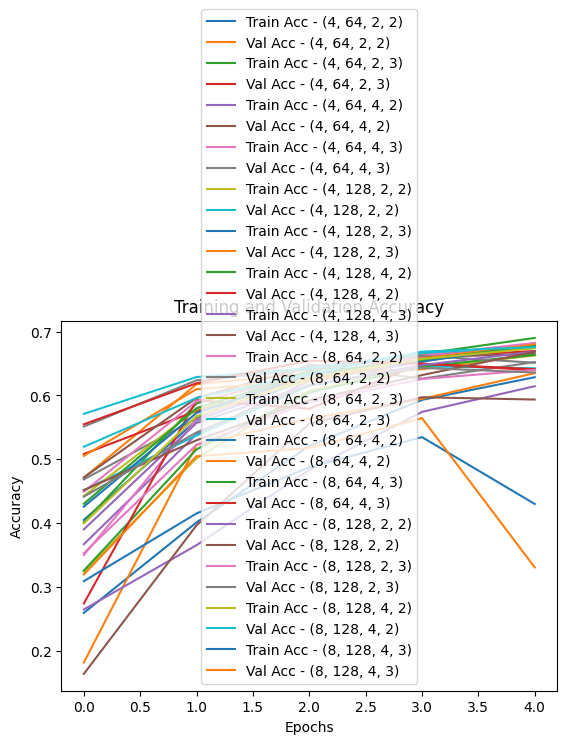

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


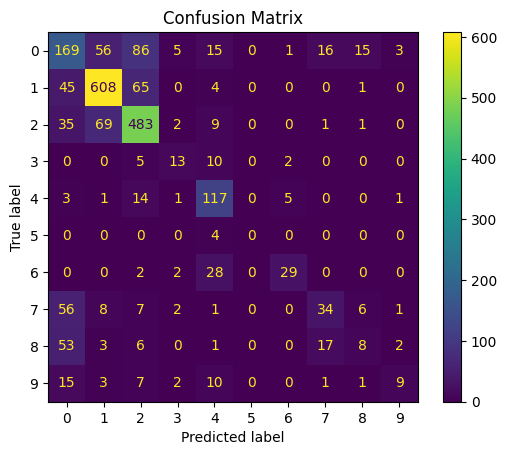

Best Model Test Accuracy: 0.6746


In [ ]:


# Load Galaxy10 dataset
images, labels = load_galaxy10sdss()
labels = tf.keras.utils.to_categorical(labels, 10)
images = images.astype(np.float32) / 255.0  # Normalize images

# Split data
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.1)

# Function to create ViT model
def create_vit_model(patch_size, num_patches, embed_dim, num_heads, mlp_dim, num_layers, dropout_rate):
    input_layer = layers.Input(shape=(train_images.shape[1], train_images.shape[2], train_images.shape[3]))

    # Patch Embedding
    patches = layers.Conv2D(filters=embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid")(input_layer)
    patches_flat = layers.Reshape((num_patches, embed_dim))(patches)


    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)(positions)
    embeddings = patches_flat + pos_embedding


    for _ in range(num_layers):
        # Multi-head Attention
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(embeddings, embeddings)
        attention_output = layers.Dropout(dropout_rate)(attention_output)
        attention_output = layers.LayerNormalization(epsilon=1e-6)(attention_output + embeddings)


        mlp_output = layers.Dense(mlp_dim, activation='relu')(attention_output)
        mlp_output = layers.Dropout(dropout_rate)(mlp_output)
        mlp_output = layers.Dense(embed_dim)(mlp_output)
        embeddings = layers.LayerNormalization(epsilon=1e-6)(mlp_output + attention_output)

    # Classification Head
    representation = layers.Flatten()(embeddings)
    output_layer = layers.Dense(10, activation='softmax')(representation)

    return tf.keras.Model(inputs=input_layer, outputs=output_layer)

# Hyperparameter
embed_dims = [64, 128]
num_heads = [2, 4]
num_layers_list = [2, 3]

# Grid search over hyperparameters
best_model = None
best_accuracy = 0.0
history_dict = {}

for patch_size, embed_dim, num_heads, num_layers in itertools.product(patch_sizes, embed_dims, num_heads, num_layers_list):
    print(f"Training model with Patch Size: {patch_size}, Embed Dim: {embed_dim}, Num Heads: {num_heads}, Num Layers: {num_layers}")

    num_patches = (train_images.shape[1] // patch_size) ** 2
    vit_model = create_vit_model(patch_size, num_patches, embed_dim, num_heads, mlp_dim=embed_dim*2, num_layers=num_layers, dropout_rate=0.1)


    vit_model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    # Train model
    history = vit_model.fit(train_images, train_labels, validation_split=0.1, epochs=5, batch_size=32, verbose=1)
    history_dict[(patch_size, embed_dim, num_heads, num_layers)] = history


    accuracy = vit_model.evaluate(test_images, test_labels, verbose=0)


    if accuracy > best_accuracy:
        best_model = vit_model
        best_accuracy = accuracy

    print(f"Model with Patch Size: {patch_size}, Embed Dim: {embed_dim}, Num Heads: {num_heads}, Num Layers: {num_layers} achieved Test Accuracy: {accuracy:.4f}")

# Plot metrics for each configuration
for key, hist in history_dict.items():
    plt.plot(hist.history['accuracy'], label=f'Train Acc - {key}')
    plt.plot(hist.history['val_accuracy'], label=f'Val Acc - {key}')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate best model
predicted_labels = np.argmax(best_model.predict(test_images), axis=1)
true_labels = np.argmax(test_labels, axis=1)

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf_matrix = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=range(10))
disp.plot(cmap='viridis')
plt.title("Confusion Matrix")
plt.show()

print(f"Best Model Test Accuracy: {best_accuracy:.4f}")


In [ ]:
! pip install torch torch-geometric
! torch-sparse torch-scatter

  Using cached torch_geometric-2.6.1-py3-none-any.whl.metadata (63 kB)
Using cached torch_geometric-2.6.1-py3-none-any.whl (1.1 MB)
/bin/bash: line 1: torch-sparse: command not found


/root/.astroNN/datasets/Galaxy10.h5 was found!


Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Epoch 1/5
218/218 - 28s - 127ms/step - accuracy: 0.4697 - loss: 1.3381 - val_accuracy: 0.3262 - val_loss: 2.1732
Epoch 2/5
218/218 - 23s - 104ms/step - accuracy: 0.6289 - loss: 0.9613 - val_accuracy: 0.3437 - val_loss: 1.8960
Epoch 3/5
218/218 - 10s - 46ms/step - accuracy: 0.7226 - loss: 0.7394 - val_accuracy: 0.6245 - val_loss: 0.9873
Epoch 4/5
218/218 - 10s - 46ms/step - accuracy: 0.7528 - loss: 0.6614 - val_accuracy: 0.7470 - val_loss: 0.7624
Epoch 5/5
218/218 - 6s - 29ms/step - accuracy: 0.7779 - loss: 0.6027 - val_accuracy: 0.6925 - val_loss: 0.7618
Test Accuracy: 0.6966


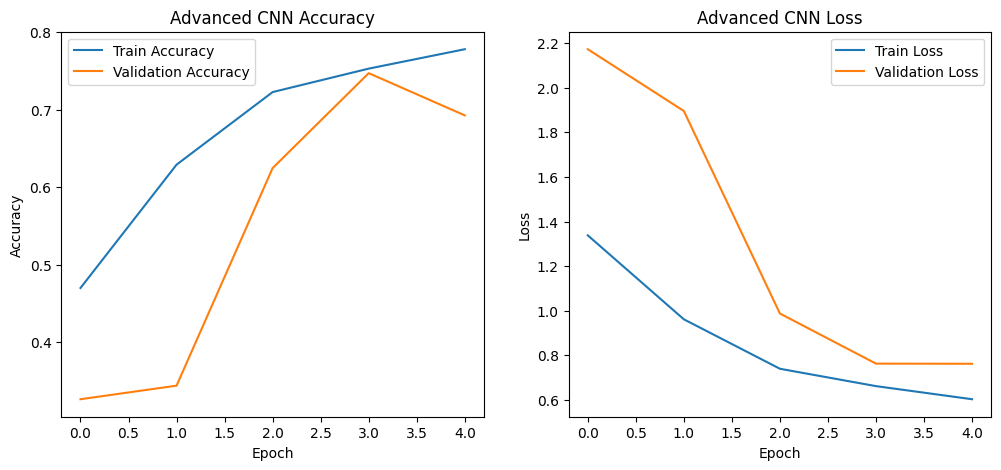

In [ ]:


# Load Galaxy10 dataset
images, labels = load_galaxy10sdss()
labels = tf.keras.utils.to_categorical(labels, 10)
images = images.astype('float32') / 255.0

# Split the dataset
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

# Function to create an advanced CNN architecture
def create_advanced_cnn(input_shape, num_classes):
    input_layer = layers.Input(shape=input_shape)


    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)


    y = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    y = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(y)
    y = layers.MaxPooling2D((2, 2))(y)
    y = layers.BatchNormalization()(y)

    z = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(y)
    z = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(z)
    z = layers.MaxPooling2D((2, 2))(z)
    z = layers.BatchNormalization()(z)


    x = layers.GlobalAveragePooling2D()(x)
    y = layers.GlobalAveragePooling2D()(y)
    z = layers.GlobalAveragePooling2D()(z)

    #Combine features
    combined = layers.Concatenate()([x, y, z])
    combined = layers.Dense(256, activation='relu')(combined)
    combined = layers.Dropout(0.5)(combined)

    # Output layer
    output_layer = layers.Dense(num_classes, activation='softmax')(combined)

    # Model
    model = models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train and evaluate the model
advanced_cnn = create_advanced_cnn((69, 69, 3), 10)
with tf.device('/GPU:0' if tf.test.is_gpu_available() else '/CPU:0'):
    history = advanced_cnn.fit(
        train_images, train_labels,
        validation_data=(val_images, val_labels),
        epochs=5,
        batch_size=64,
        verbose=2
    )


test_loss, test_acc = advanced_cnn.evaluate(test_images, test_labels, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Advanced CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Advanced CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


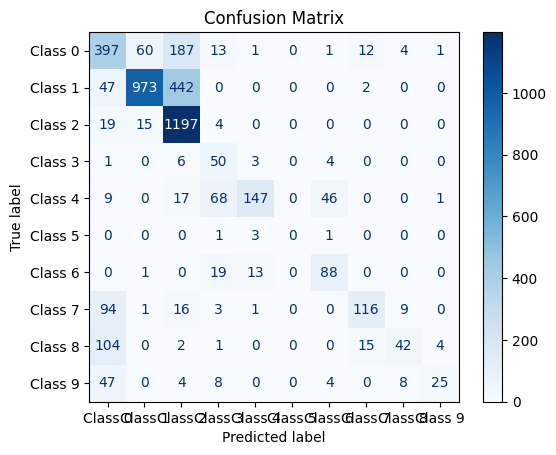

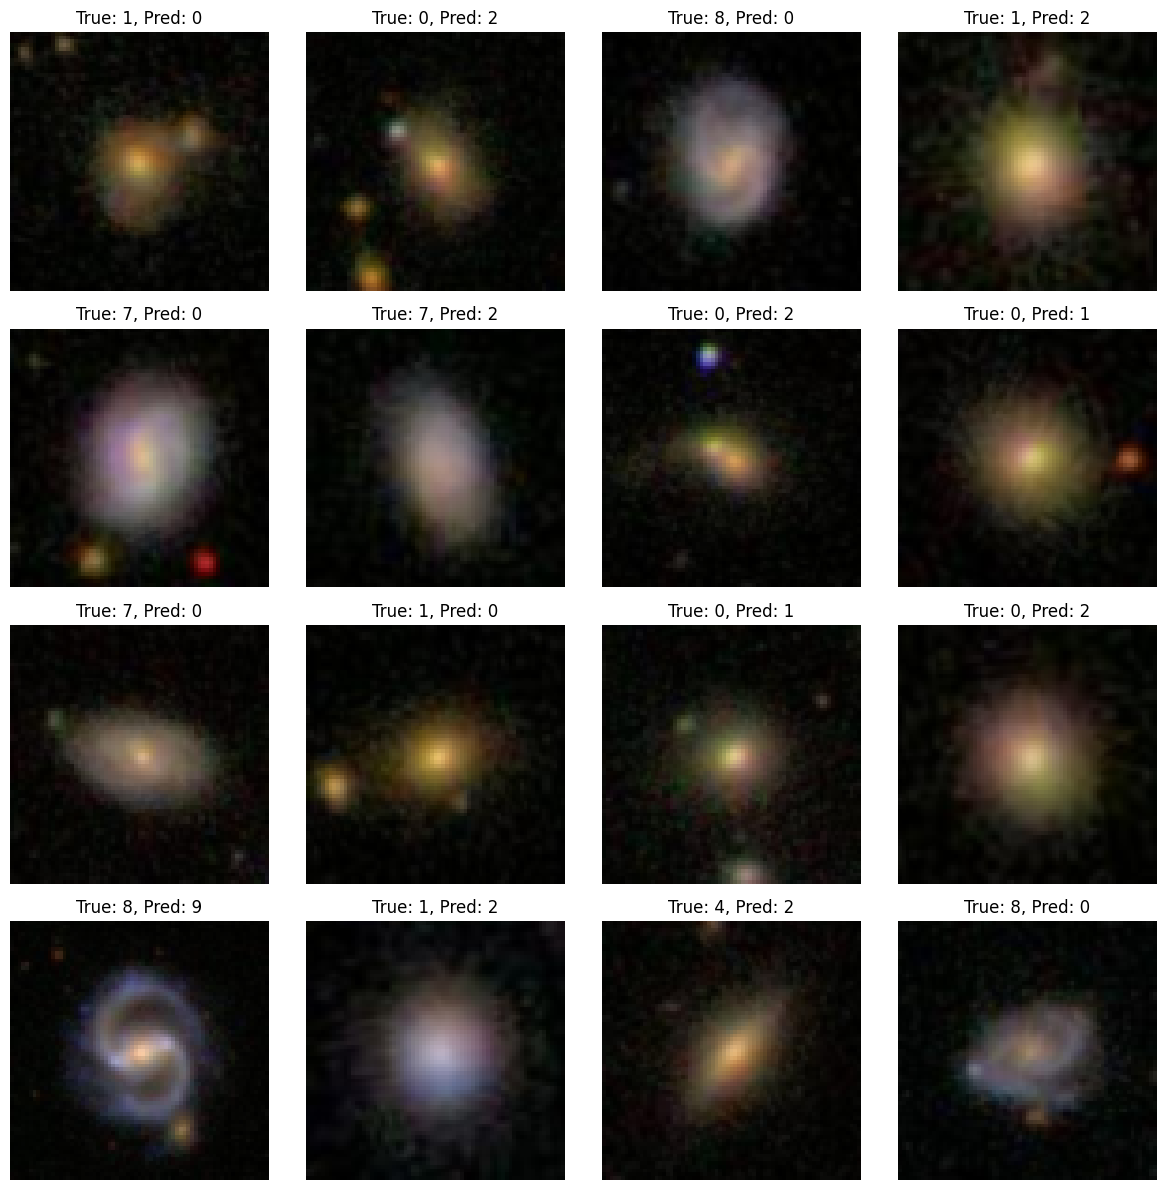

In [ ]:

predictions = np.argmax(advanced_cnn.predict(test_images), axis=1)
true_labels = np.argmax(test_labels, axis=1)
cm = confusion_matrix(true_labels, predictions)
ConfusionMatrixDisplay(cm, display_labels=[f"Class {i}" for i in range(10)]).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Visualize misclassified images
misclassified_indices = np.where(predictions != true_labels)[0]

plt.figure(figsize=(12, 12))
for i, idx in enumerate(misclassified_indices[:16]):  # Display up to 16 misclassified images
    plt.subplot(4, 4, i + 1)
    plt.imshow(test_images[idx])
    plt.title(f"True: {true_labels[idx]}, Pred: {predictions[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Num GPUs Available:  1
Using GPU for training!
/root/.astroNN/datasets/Galaxy10.h5 was found!
Epoch 1/5
Loss after epoch 1: 2.2952938079833984
Epoch 2/5
Loss after epoch 2: 2.148515462875366
Epoch 3/5
Loss after epoch 3: 2.0512354373931885
Epoch 4/5
Loss after epoch 4: 1.894067406654358
Epoch 5/5
Loss after epoch 5: 1.7742379903793335


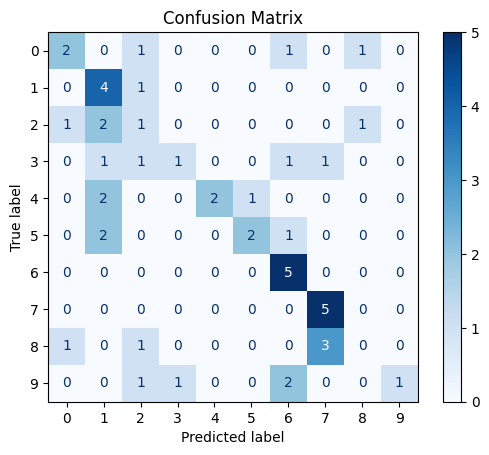

Showing some misclassified images:


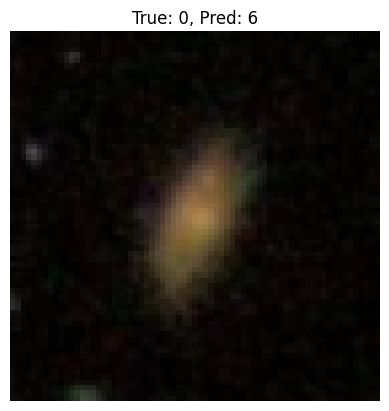

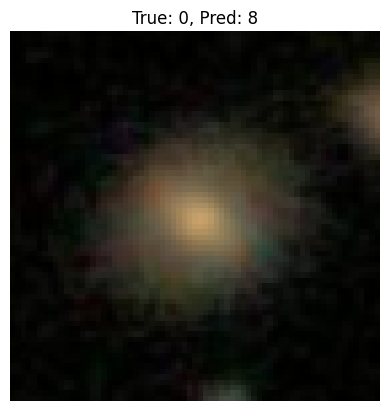

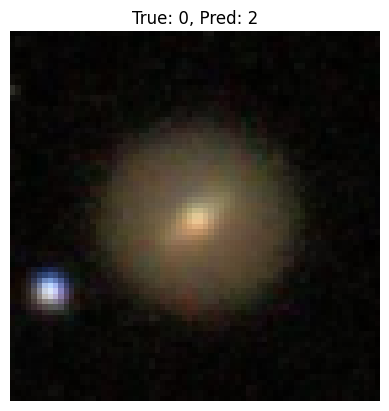

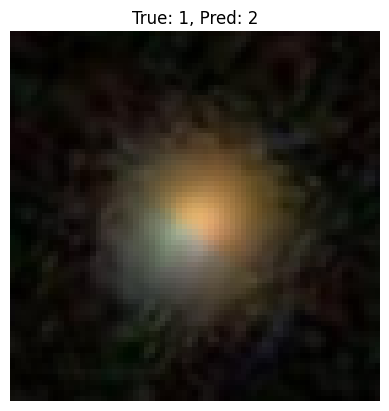

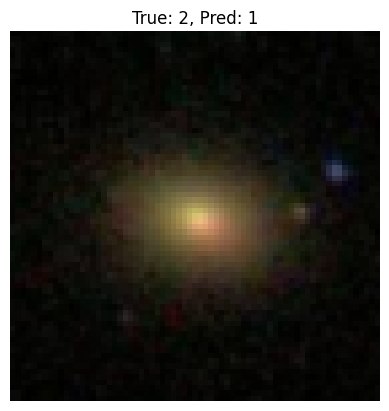

In [ ]:


images, labels = load_galaxy10sdss()
labels = labels.astype(np.int32)
images = images.astype('float32') / 255.0


n_classes = 10
n_support = 5
n_query = 5
epochs = 5
batch_size = 32


class PrototypeNetwork(tf.keras.Model):
    def __init__(self, input_shape):
        super(PrototypeNetwork, self).__init__()
        self.encoder = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), activation='relu'),
            layers.MaxPooling2D((2, 2)),
            layers.Flatten(),
            layers.Dense(128, activation='relu')
        ])

    def call(self, x):
        return self.encoder(x)


def create_few_shot_split(images, labels, n_classes, n_support, n_query):
    support_images, support_labels = [], []
    query_images, query_labels = [], []

    for cls in range(n_classes):
        cls_indices = np.where(labels == cls)[0]
        if len(cls_indices) < n_support + n_query:
            print(f"Class {cls} has only {len(cls_indices)} samples. Adjusting n_support and n_query.")
            n_query = len(cls_indices) - n_support

        selected_indices = np.random.choice(cls_indices, n_support + n_query, replace=False)
        support_indices = selected_indices[:n_support]
        query_indices = selected_indices[n_support:]

        support_images.append(images[support_indices])
        support_labels.append(labels[support_indices])
        query_images.append(images[query_indices])
        query_labels.append(labels[query_indices])

    return (np.concatenate(support_images), np.concatenate(support_labels),
            np.concatenate(query_images), np.concatenate(query_labels))

#  class prototypes
def compute_prototypes(encoder, support_images, support_labels, n_classes):
    prototypes = []
    for cls in range(n_classes):
        cls_indices = np.where(support_labels == cls)[0]
        cls_features = encoder(support_images[cls_indices])
        prototypes.append(tf.reduce_mean(cls_features, axis=0))
    return tf.stack(prototypes)

# Predict using prototypes
def predict(encoder, query_images, prototypes):
    query_features = encoder(query_images)
    distances = tf.reduce_sum((tf.expand_dims(query_features, 1) - tf.expand_dims(prototypes, 0))**2, axis=2)
    return tf.nn.softmax(-distances, axis=1)

#t data split
support_images, support_labels, query_images, query_labels = create_few_shot_split(
    images, labels, n_classes, n_support, n_query)

proto_net = PrototypeNetwork(input_shape=(69, 69, 3))
optimizer = tf.keras.optimizers.Adam()

# training loop
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    with tf.GradientTape() as tape:
        prototypes = compute_prototypes(proto_net.encoder, support_images, support_labels, n_classes)


        predictions = predict(proto_net.encoder, query_images, prototypes)


        if query_labels.shape[0] > predictions.shape[0]:
            query_labels = query_labels[:predictions.shape[0]]

        # Compute loss
        loss = tf.keras.losses.sparse_categorical_crossentropy(query_labels, predictions)

    # Backpropagation
    grads = tape.gradient(loss, proto_net.trainable_weights)
    optimizer.apply_gradients(zip(grads, proto_net.trainable_weights))

    print(f"Loss after epoch {epoch+1}: {tf.reduce_mean(loss).numpy()}")

# Evaluation
prototypes = compute_prototypes(proto_net.encoder, support_images, support_labels, n_classes)
predictions = predict(proto_net.encoder, query_images, prototypes)
predicted_classes = tf.argmax(predictions, axis=1)

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(query_labels, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(n_classes))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# misclassified images
misclassified = np.where(predicted_classes != query_labels)[0]
if len(misclassified) > 0:
    print("Showing some misclassified images:")
    for i in misclassified[:5]:  # Show up to 5 misclassified images
        plt.imshow(query_images[i])
        plt.title(f"True: {query_labels[i]}, Pred: {predicted_classes[i]}")
        plt.axis('off')
        plt.show()
else:
    print("No misclassified images found.")
